### 4.1 Coding an LLM architecture

In [ ]:
import torch
import torch.nn as nn
import tiktoken

In [ ]:
torch.__version__

'2.10.0+cu128'

In [ ]:
GPT_CONFIG_124M = {
 "vocab_size": 50257, # Vocabulary size
 "context_length": 1024, # Context length
 "emb_dim": 768, # Embedding dimension
 "n_heads": 12, # Number of attention heads
 "n_layers": 12, # Number of layers
 "drop_rate": 0.1, # Dropout rate
 "qkv_bias": False # Query-Key-Value bias
}

In [ ]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg['context_length'], cfg['emb_dim'])
        self.drop_emb = nn.Dropout(cfg['drop_rate'])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg['n_layers'])]
            )
        self.final_norm = DummyLayerNorm(cfg['emb_dim'])
        self.out_head = nn.Linear(cfg['emb_dim'], cfg['vocab_size'], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
            )

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)

        return logits

In [ ]:
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    
    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    
    def forward(self, x):
        return x

In [ ]:
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

In [ ]:
tokenizer = tiktoken.get_encoding('gpt2')

In [ ]:
batch = []
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

batch

[tensor([6109, 3626, 6100,  345]), tensor([6109, 1110, 6622,  257])]

In [ ]:
batch = torch.stack(batch)
batch

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

In [ ]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
output = model(batch)

In [ ]:
print(output.shape)
output

torch.Size([2, 4, 50257])


tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)

In [ ]:
te = model.tok_emb(batch)
print(te.shape)
te

torch.Size([2, 4, 768])


tensor([[[ 1.6146,  2.1622,  1.2770,  ...,  0.0111, -1.1353, -0.2450],
         [-1.6020, -1.3996,  0.4308,  ...,  0.0913, -0.0614, -0.0538],
         [ 0.7265,  1.0869, -0.2251,  ..., -0.0742,  0.1081,  0.9774],
         [-0.4047, -0.0914, -1.5747,  ..., -1.5130,  0.4232,  0.5841]],

        [[ 1.6146,  2.1622,  1.2770,  ...,  0.0111, -1.1353, -0.2450],
         [-0.7858,  0.0101,  1.2537,  ..., -0.2667, -0.7853,  1.3047],
         [ 1.8873,  0.7559, -0.1797,  ..., -0.0418, -0.4365, -0.3167],
         [ 1.2758, -0.2896,  0.9539,  ...,  0.3405, -1.0636, -0.0674]]],
       grad_fn=<EmbeddingBackward0>)

### 4.2 Normalizing activations with layer normalization (LayerNorm)

In [ ]:
torch.manual_seed(123)
batch_example = torch.rand(2,5)
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())

out = layer(batch_example)
out


tensor([[0.0000, 0.0000, 0.4091, 0.6587, 0.3914, 0.0000],
        [0.0000, 0.0000, 0.1902, 0.3182, 0.6486, 0.0000]],
       grad_fn=<ReluBackward0>)

In [ ]:
mean = out.mean(dim=1, keepdim=True)
mean

tensor([[0.2432],
        [0.1928]], grad_fn=<MeanBackward1>)

In [ ]:
var = out.var(dim=1, keepdim=True)
var

tensor([[0.0799],
        [0.0670]], grad_fn=<VarBackward0>)

In [ ]:
norm_out = (out - mean) / torch.sqrt(var)
norm_out

tensor([[-0.8603, -0.8603,  0.5869,  1.4698,  0.5242, -0.8603],
        [-0.7450, -0.7450, -0.0102,  0.4844,  1.7608, -0.7450]],
       grad_fn=<DivBackward0>)

In [ ]:
norm_out.mean(dim=1, keepdim=True)

tensor([[ 0.0000e+00],
        [-2.9802e-08]], grad_fn=<MeanBackward1>)

In [ ]:
norm_out.var(dim=1, keepdim=True)

tensor([[1.],
        [1.]], grad_fn=<VarBackward0>)

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-05
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return norm_x * self.scale + self.shift

In [ ]:
batch_example

tensor([[0.2961, 0.5166, 0.2517, 0.6886, 0.0740],
        [0.8665, 0.1366, 0.1025, 0.1841, 0.7264]])

In [ ]:
ln = LayerNorm(emb_dim=5)
ln_out = ln(batch_example)

ln_out

tensor([[-0.3230,  0.7050, -0.5302,  1.5070, -1.3588],
        [ 1.4248, -0.8200, -0.9248, -0.6740,  0.9940]])

In [ ]:
ln_out.mean(dim=-1, keepdim=True)

tensor([[ 2.3842e-08],
        [-8.3447e-08]])

In [ ]:
ln_out.var(dim=-1, keepdim=True, unbiased=False)

tensor([[1.0000],
        [1.0000]])

### 4.3 Implementing a feed forward networkwith GELU activations

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) *
        (x + 0.044715 * torch.pow(x, 3)))
        )

In [ ]:
gelu, relu = GELU(), nn.ReLU()

In [ ]:
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

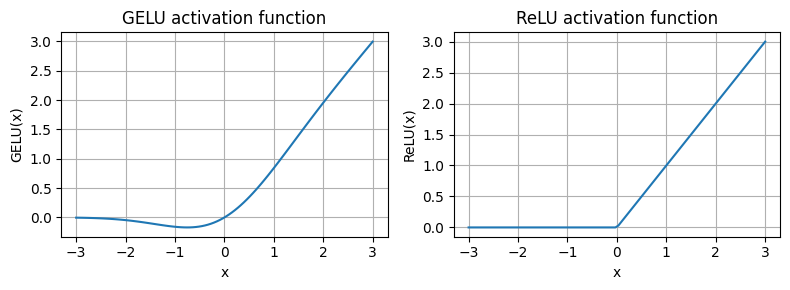

In [ ]:
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show();

In [ ]:
y_gelu

tensor([-0.0036, -0.0044, -0.0053, -0.0063, -0.0076, -0.0090, -0.0106, -0.0124,
        -0.0145, -0.0169, -0.0196, -0.0225, -0.0259, -0.0295, -0.0336, -0.0380,
        -0.0428, -0.0481, -0.0537, -0.0597, -0.0660, -0.0728, -0.0798, -0.0871,
        -0.0947, -0.1024, -0.1102, -0.1180, -0.1257, -0.1332, -0.1404, -0.1472,
        -0.1534, -0.1588, -0.1634, -0.1669, -0.1691, -0.1700, -0.1694, -0.1669,
        -0.1626, -0.1562, -0.1476, -0.1366, -0.1232, -0.1071, -0.0882, -0.0666,
        -0.0422, -0.0148,  0.0155,  0.0487,  0.0849,  0.1239,  0.1657,  0.2102,
         0.2573,  0.3069,  0.3589,  0.4131,  0.4694,  0.5276,  0.5875,  0.6490,
         0.7119,  0.7760,  0.8412,  0.9072,  0.9740,  1.0414,  1.1092,  1.1773,
         1.2457,  1.3141,  1.3825,  1.4508,  1.5189,  1.5869,  1.6545,  1.7218,
         1.7888,  1.8554,  1.9216,  1.9875,  2.0529,  2.1179,  2.1826,  2.2469,
         2.3108,  2.3744,  2.4377,  2.5006,  2.5633,  2.6258,  2.6880,  2.7500,
         2.8118,  2.8735,  2.9350,  2.99

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg['emb_dim'], 4* cfg['emb_dim']),
            GELU(),
            nn.Linear(4*cfg['emb_dim'], cfg['emb_dim'])
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2,3,768)
out = ffn(x)

print(out.shape)
out

torch.Size([2, 3, 768])


tensor([[[ 0.1248,  0.1759,  0.0161,  ...,  0.0064, -0.0337, -0.0174],
         [ 0.0219,  0.1710,  0.0286,  ...,  0.0420, -0.1005, -0.0635],
         [-0.0508,  0.1427, -0.0003,  ..., -0.1186, -0.0030,  0.0563]],

        [[-0.0040,  0.2318,  0.0615,  ..., -0.0554, -0.0870, -0.0154],
         [-0.1318,  0.2149,  0.0284,  ...,  0.0057,  0.0609,  0.0169],
         [ 0.0464,  0.1828,  0.0760,  ..., -0.0817, -0.0679, -0.0356]]],
       grad_fn=<ViewBackward0>)

### 4.4 Adding shortcut connections

In [ ]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layers_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]),
            GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_out = layer(x)
            
            if self.use_shortcut and x.shape == layer_out.shape:
                x = x + layer_out
            else:
                x = layer_out

        return x

In [ ]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])

sample_input.shape

torch.Size([1, 3])

In [ ]:
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
 layer_sizes, use_shortcut=False
)

In [ ]:
def get_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)
    loss.backward()
    

In [ ]:
get_gradients(model_without_shortcut, sample_input)

In [ ]:
def print_gradients(model):
    for name, params in model.layers.named_parameters():
        print(name)
        if 'weight' in name:
            print(f'Layer: {name}, abs mean gradient: {params.grad.abs().mean().item()}')

In [ ]:
print_gradients(model_without_shortcut)

0.0.weight
Layer: 0.0.weight, abs mean gradient: 0.00040347175672650337
0.0.bias
1.0.weight
Layer: 1.0.weight, abs mean gradient: 0.00024022319121286273
1.0.bias
2.0.weight
Layer: 2.0.weight, abs mean gradient: 0.0014304080978035927
2.0.bias
3.0.weight
Layer: 3.0.weight, abs mean gradient: 0.002797747263684869
3.0.bias
4.0.weight
Layer: 4.0.weight, abs mean gradient: 0.010099290870130062
4.0.bias


In [ ]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
get_gradients(model_with_shortcut, sample_input)

In [ ]:
print_gradients(model_with_shortcut)

0.0.weight
Layer: 0.0.weight, abs mean gradient: 0.22169798612594604
0.0.bias
1.0.weight
Layer: 1.0.weight, abs mean gradient: 0.20694111287593842
1.0.bias
2.0.weight
Layer: 2.0.weight, abs mean gradient: 0.3289700150489807
2.0.bias
3.0.weight
Layer: 3.0.weight, abs mean gradient: 0.26657330989837646
3.0.bias
4.0.weight
Layer: 4.0.weight, abs mean gradient: 1.3258544206619263
4.0.bias


### 4.5 Connecting attention and linear layers in a transformer block

In [14]:
import torch
import torch.nn as nn
import tiktoken


In [15]:
torch.__version__

'2.10.0+cu128'

In [16]:
GPT_CONFIG_124M = {
 "vocab_size": 50257, # Vocabulary size
 "context_length": 1024, # Context length
 "emb_dim": 768, # Embedding dimension
 "n_heads": 12, # Number of attention heads
 "n_layers": 12, # Number of layers
 "drop_rate": 0.1, # Dropout rate
 "qkv_bias": False # Query-Key-Value bias
}

In [17]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) *
        (x + 0.044715 * torch.pow(x, 3)))
        )

In [18]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']),
            GELU(),
            nn.Linear(4*cfg['emb_dim'], cfg['emb_dim'])
        )

    def forward(self, x):
        return self.layers(x)

In [19]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-05
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return norm_x * self.scale + self.shift

In [20]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out,
                 context_length,
                 dropout,
                 num_heads,
                 qkv_bias=False):
        
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)  # -> (b, num_tokens, d_out)
        querys = self.W_query(x)  # -> (b, num_tokens, d_out)
        values = self.W_value(x)  # -> (b, num_tokens, d_out)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim ) # -> (b, num_tokens, num_heads, head_dim)
        querys = querys.view(b, num_tokens, self.num_heads, self.head_dim ) # -> (b, num_tokens, num_heads, head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim ) # -> (b, num_tokens, num_heads, head_dim)

        keys = keys.transpose(1,2)    # -> (b, num_heads, num_tokens, head_dim)
        querys = querys.transpose(1,2)   # -> (b, num_heads, num_tokens, head_dim)
        values = values.transpose(1,2)   # -> (b, num_heads, num_tokens, head_dim)

        attn_scores_ = querys @ keys.transpose(2,3)  # -> (b, num_heads, num_tokens, num_tokens)

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores_.masked_fill_(mask_bool, -torch.inf)

        attn_weights = self.dropout(
            torch.softmax(attn_scores_ / keys.shape[-1]**0.5, dim=-1))  # -> (b, num_heads, num_tokens, num_tokens)

        context_vecs = attn_weights @ values  # -> (b, num_heads, num_tokens, head_dim)
        context_vecs = context_vecs.transpose(1,2)   # -> (b, num_tokens, num_heads, head_dim)
        context_vecs = context_vecs.contiguous().view(b, num_tokens, self.d_out)   # -> (b, num_tokens, d_out)
        context_vecs = self.out_proj(context_vecs)   # -> (b, num_tokens, d_out)

        return context_vecs   # -> (b, num_tokens, d_out)


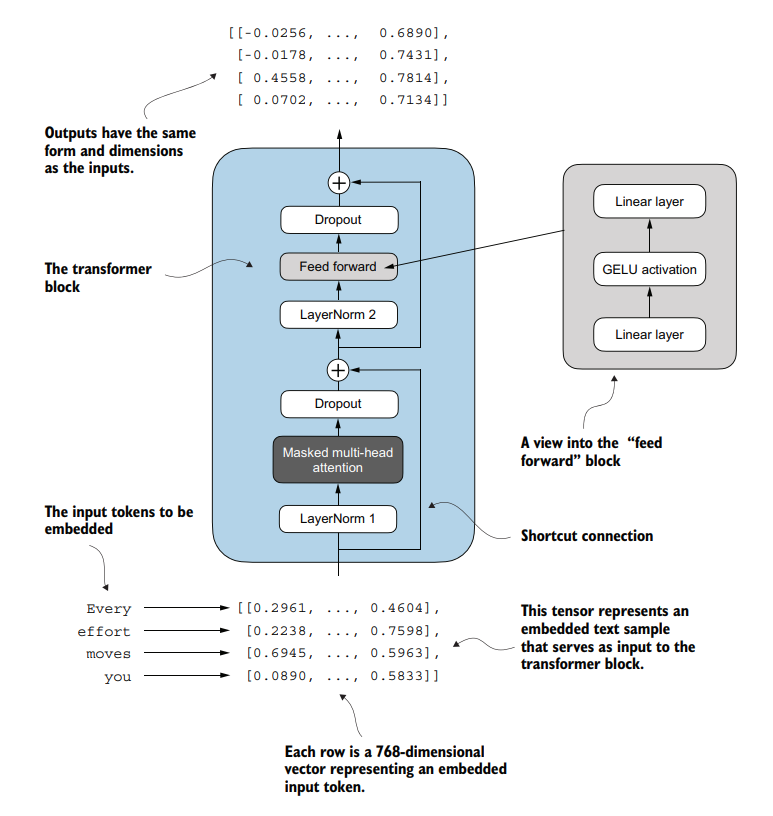

In [21]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg['emb_dim'],
            d_out=cfg['emb_dim'],
            context_length=cfg['context_length'],
            dropout=cfg['drop_rate'],
            num_heads=cfg['n_heads'],
            qkv_bias=cfg['qkv_bias']
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg['emb_dim'])
        self.norm2 = LayerNorm(cfg['emb_dim'])
        self.drop_shortcut = nn.Dropout(cfg['drop_rate'])

    
    def forward(self, x):
        x1 = self.norm1(x)
        x1 = self.att(x1)
        x1 = self.drop_shortcut(x1) + x

        x2 = self.norm2(x1)
        x2 = self.ff(x2)
        out = self.drop_shortcut(x2) + x1

        return out 

In [22]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)

block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

In [23]:
print(output.shape)
output

torch.Size([2, 4, 768])


tensor([[[ 0.3110,  0.6988,  0.0345,  ...,  1.5609,  0.7526,  0.4869],
         [ 0.6074, -0.1933, -0.1014,  ...,  0.5767,  0.3514,  0.5988],
         [ 0.6150,  0.1620, -0.0052,  ...,  1.0019,  0.3858,  0.3943],
         [-0.1885,  0.7804,  0.5608,  ...,  0.7196,  0.4096,  0.6010]],

        [[ 0.0337,  0.5356,  0.1099,  ...,  0.3724,  0.3196, -0.0696],
         [-0.1347,  0.4514,  0.1923,  ...,  0.6758,  0.0379,  0.6792],
         [ 0.5210, -0.1000, -0.1165,  ...,  0.4467,  0.5217, -0.5697],
         [ 0.2037,  0.5176,  0.4256,  ...,  1.2745,  1.1949,  0.0030]]],
       grad_fn=<AddBackward0>)

### 4.6 Coding the GPT model

In [ ]:
# Dummy architecture from chapter 4.1

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg['context_length'], cfg['emb_dim'])
        self.drop_emb = nn.Dropout(cfg['drop_rate'])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg['n_layers'])]
            )
        self.final_norm = DummyLayerNorm(cfg['emb_dim'])
        self.out_head = nn.Linear(cfg['emb_dim'], cfg['vocab_size'], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
            )

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)

        return logits

![Screenshot 2025-09-25 165027.png](<attachment:Screenshot 2025-09-25 165027.png>)
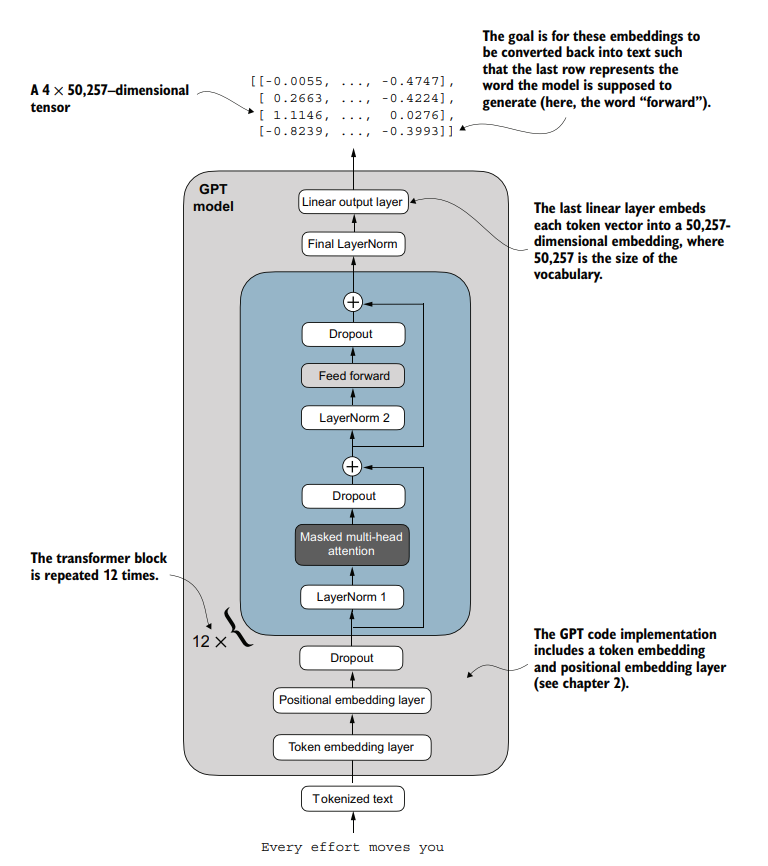

In [24]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg['context_length'], cfg['emb_dim'])
        self.drop_emb = nn.Dropout(cfg['drop_rate'])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg['n_layers'])]
            )
        self.final_norm = LayerNorm(cfg['emb_dim'])
        self.out_head = nn.Linear(cfg['emb_dim'], cfg['vocab_size'], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)    # -> (batch_size, seq_len, emb_dim)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)   # -> (seq_len, emb_dim)
            )

        x = tok_embeds + pos_embeds       # -> (batch_size, seq_len, emb_dim)
        x = self.drop_emb(x)              # -> (batch_size, seq_len, emb_dim)
        x = self.trf_blocks(x)            # -> (batch_size, seq_len, emb_dim)
        x = self.final_norm(x)            # -> (batch_size, seq_len, emb_dim)
        logits = self.out_head(x)         # -> (batch_size, seq_len, vocab_size)

        return logits

In [25]:

batch = torch.tensor(
    [[6109, 3626, 6100, 345],    # Token IDs of text 1
     [6109, 1110, 6622, 257]]    # Token IDs of text 2
     )

In [26]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

output = model(batch)

In [ ]:
print(output.shape)
output

torch.Size([2, 4, 50257])


tensor([[[-0.6273, -0.1458,  0.1839,  ..., -0.6657, -0.4855, -0.7900],
         [-0.1409, -0.7438, -0.5887,  ...,  0.0630, -0.3328, -0.4963],
         [ 0.2327,  0.3319, -0.0906,  ...,  0.4180, -0.0515,  0.4808],
         [-0.3546, -0.3463,  1.1268,  ...,  0.5482,  0.3462,  0.3439]],

        [[-0.7103, -0.2001,  0.0363,  ..., -0.2801, -0.5357, -0.6127],
         [-0.5180, -0.5335, -0.4314,  ..., -0.8589, -0.7721, -0.0991],
         [ 0.5569, -0.1870,  0.4450,  ..., -0.4347, -0.3596,  0.4438],
         [-0.0673, -0.4346,  0.7289,  ...,  0.9010,  0.3200,  0.1675]]],
       grad_fn=<UnsafeViewBackward0>)

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,000,320


In [ ]:
model.tok_emb.weight.shape, model.out_head.weight.shape 

(torch.Size([50257, 768]), torch.Size([50257, 768]))

In [ ]:
tot_params = total_params - model.out_head.weight.numel()
tot_params

124402944

#### Exercise 4.1 Number of parameters in feed forward and attention modules 

In [ ]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_key): Linear(in_features

In [ ]:
def count_parameters(layer_name:str):
    return sum(
        p.numel() for n,p in model.trf_blocks[0].named_parameters() if layer_name in n
        )

In [ ]:
print(f'FF: {count_parameters('ff'):,} parameters')

FF: 4,722,432 parameters


In [ ]:
print(f'ATT: {count_parameters('att'):,} parameters')

ATT: 2,359,296 parameters


#### Exercise 4.2 Initializing larger GPT models

In [ ]:
configs = {
    'min': {
        "vocab_size": 50257, # Vocabulary size
        "context_length": 1024, # Context length
        "emb_dim": 768, # Embedding dimension
        "n_heads": 12, # Number of attention heads
        "n_layers": 12, # Number of layers
        "drop_rate": 0.1, # Dropout rate
        "qkv_bias": False # Query-Key-Value bias
        },
    'medium': {
        "vocab_size": 50257, # Vocabulary size
        "context_length": 1024, # Context length
        "emb_dim": 1024, # Embedding dimension
        "n_heads": 16, # Number of attention heads
        "n_layers": 24, # Number of layers
        "drop_rate": 0.1, # Dropout rate
        "qkv_bias": False # Query-Key-Value bias
        },
    'large': {
        "vocab_size": 50257, # Vocabulary size
        "context_length": 1024, # Context length
        "emb_dim": 1280, # Embedding dimension
        "n_heads": 20, # Number of attention heads
        "n_layers": 36, # Number of layers
        "drop_rate": 0.1, # Dropout rate
        "qkv_bias": False # Query-Key-Value bias
        },
    'xl': {
        "vocab_size": 50257, # Vocabulary size
        "context_length": 1024, # Context length
        "emb_dim": 1600, # Embedding dimension
        "n_heads": 25, # Number of attention heads
        "n_layers": 48, # Number of layers
        "drop_rate": 0.1, # Dropout rate
        "qkv_bias": False # Query-Key-Value bias
        }
}

In [ ]:
# Use Colab server for the calculations
for size, cfg in configs.items():
    print(size.upper(), end=':')
    gpt = GPTModel(cfg)
    tot_p = sum(p.numel() for p in gpt.parameters())
    memory = tot_p * 4 / 1024**2
    print(f' {tot_p / 1e+6:.2f}M parameters ({memory:.2f} Mb)')
    del gpt

MIN: 163.00M parameters (621.80 Mb)
MEDIUM: 406.19M parameters (1549.48 Mb)
LARGE: 838.17M parameters (3197.38 Mb)
XL: 1637.72M parameters (6247.39 Mb)


### 4.7 Generating text

In [1]:
import torch
import torch.nn as nn
import tiktoken

In [12]:
GPT_CONFIG_124M = {
 "vocab_size": 50257, # Vocabulary size
 "context_length": 1024, # Context length
 "emb_dim": 768, # Embedding dimension
 "n_heads": 12, # Number of attention heads
 "n_layers": 12, # Number of layers
 "drop_rate": 0.1, # Dropout rate
 "qkv_bias": False # Query-Key-Value bias
}

In [35]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_key): Linear(in_features

In [2]:
def generate_text_simple(
    model,
    idx,        # (batch, num_tokens)
    max_new_tokens,
    context_size):

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]   # crop the tocken sequence to the last `context_size` tokens

        with torch.no_grad():
            logits = model(idx_cond)        # (batch, num_tockens, vocab_size)
        
        logits = logits[:, -1, :]  # take the last row in each batch -> (batch, vocab_size)
        probs = torch.softmax(logits, dim=-1)                 # (batch, vocab_size)
        new_idx = torch.argmax(probs, dim=-1, keepdim=True)   # (batch, 1)

        idx = torch.cat((idx, new_idx), dim=1)                # (batch, num_tokens + 1)

    return idx        

In [3]:
tokenizer = tiktoken.get_encoding('gpt2')

In [6]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)

encoded

[15496, 11, 314, 716]

In [11]:
encoded_tensor = torch.tensor(encoded).unsqueeze(0)

encoded_tensor, encoded_tensor.shape

(tensor([[15496,    11,   314,   716]]), torch.Size([1, 4]))

In [36]:
model.eval()
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,        # (batch, num_tokens)
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M['context_length']
    )

In [37]:
out, out.shape

(tensor([[15496,    11,   314,   716, 12192, 17592, 25063, 24649, 31581, 36272]]),
 torch.Size([1, 10]))

In [33]:
out[0].tolist()

[15496, 11, 314, 716, 12192, 17592, 25063, 24649, 31581, 36272]

In [34]:
decoded_text = tokenizer.decode(out[0].tolist())
decoded_text

'Hello, I amoyd prone solicit memoir Apprentice SWAT'

#### Exercise 4.3 Using separate dropout parameters 

In [ ]:
GPT_CONFIG_124M = {
 "vocab_size": 50257, # Vocabulary size
 "context_length": 1024, # Context length
 "emb_dim": 768, # Embedding dimension
 "n_heads": 12, # Number of attention heads
 "n_layers": 12, # Number of layers
 "drop_rate_emb": 0.1, # Dropout rate
 "drop_rate_att": 0.1, # Dropout rate
 "drop_rate_shortcut": 0.1, # Dropout rate
 "qkv_bias": False # Query-Key-Value bias
}

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg['emb_dim'],
            d_out=cfg['emb_dim'],
            context_length=cfg['context_length'],
            dropout=cfg['drop_rate_attn'],
            num_heads=cfg['n_heads'],
            qkv_bias=cfg['qkv_bias']
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg['emb_dim'])
        self.norm2 = LayerNorm(cfg['emb_dim'])
        self.drop_shortcut = nn.Dropout(cfg['drop_rate_shortcut'])

    
    def forward(self, x):
        x1 = self.norm1(x)
        x1 = self.att(x1)
        x1 = self.drop_shortcut(x1) + x

        x2 = self.norm2(x1)
        x2 = self.ff(x2)
        out = self.drop_shortcut(x2) + x1

        return out 

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg['context_length'], cfg['emb_dim'])
        self.drop_emb = nn.Dropout(cfg['drop_rate_emb'])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg['n_layers'])]
            )
        self.final_norm = LayerNorm(cfg['emb_dim'])
        self.out_head = nn.Linear(cfg['emb_dim'], cfg['vocab_size'], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)    # -> (batch_size, seq_len, emb_dim)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)   # -> (seq_len, emb_dim)
            )

        x = tok_embeds + pos_embeds       # -> (batch_size, seq_len, emb_dim)
        x = self.drop_emb(x)              # -> (batch_size, seq_len, emb_dim)
        x = self.trf_blocks(x)            # -> (batch_size, seq_len, emb_dim)
        x = self.final_norm(x)            # -> (batch_size, seq_len, emb_dim)
        logits = self.out_head(x)         # -> (batch_size, seq_len, vocab_size)

        return logits